Matplotlib is building the font cache; this may take a moment.


Ecuación diferencial:


Eq(2*y(t) + Derivative(y(t), t), 10)


Solución:


Eq(y(t), C1*exp(-2*t) + 5)


Solución con condición inicial y(0)=0:


Eq(y(t), 5 - 5*exp(-2*t))

,Tiempo,Y(t)
0,0.000000,0.000000
1,0.050505,0.480380
2,0.101010,0.914608
3,0.151515,1.307116
4,0.202020,1.661914
5,0.252525,1.982625
6,0.303030,2.272522
7,0.353535,2.534568
8,0.404040,2.771437
9,0.454545,2.985548


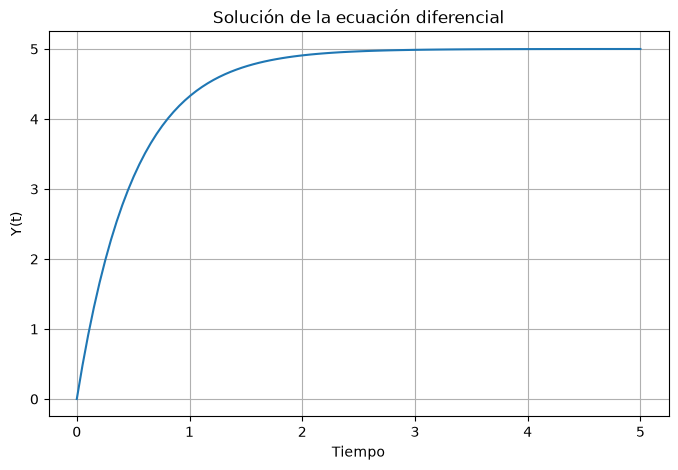

In [1]:
import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# 1. ECUACIÓN DIFERENCIAL
# ==========================================================

t = sp.symbols('t')
y = sp.Function('y')

# Ecuación: dy/dt + 2y = 10
ecuacion = sp.Eq(sp.diff(y(t), t) + 2*y(t), 10)

# Resolver
solucion = sp.dsolve(ecuacion)

print("Ecuación diferencial:")
display(ecuacion)

print("\nSolución:")
display(solucion)


# ==========================================================
# 2. APLICAR CONDICIÓN INICIAL
# y(0) = 0
# ==========================================================

condicion = sp.Eq(y(0), 0)

solucion_ci = sp.dsolve(
    ecuacion,
    ics={y(0): 0}
)

print("\nSolución con condición inicial y(0)=0:")
display(solucion_ci)


# ==========================================================
# 3. CONVERTIR LA SOLUCIÓN A FUNCIÓN NUMÉRICA
# ==========================================================

funcion = sp.lambdify(t, solucion_ci.rhs, 'numpy')

tiempo = np.linspace(0, 5, 100)
valores = funcion(tiempo)


# ==========================================================
# 4. CREAR UNA TABLA CON PANDAS
# ==========================================================

datos = pd.DataFrame({
    'Tiempo': tiempo,
    'Y(t)': valores
})

display(datos.head(10))


# ==========================================================
# 5. GRAFICAR
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(tiempo, valores)

plt.xlabel("Tiempo")
plt.ylabel("Y(t)")
plt.title("Solución de la ecuación diferencial")

plt.grid(True)
plt.show()